In [17]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [18]:
df = pd.read_csv("heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


EDA & Data Cleaning

In [19]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [20]:
df.shape

(918, 12)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [22]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [23]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

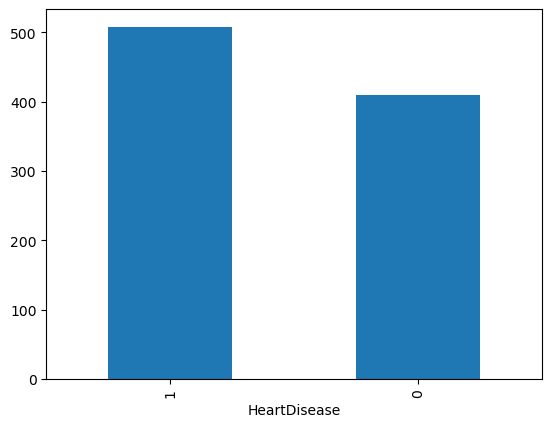

In [24]:
df['HeartDisease'].value_counts().plot(kind = "bar")

In [25]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

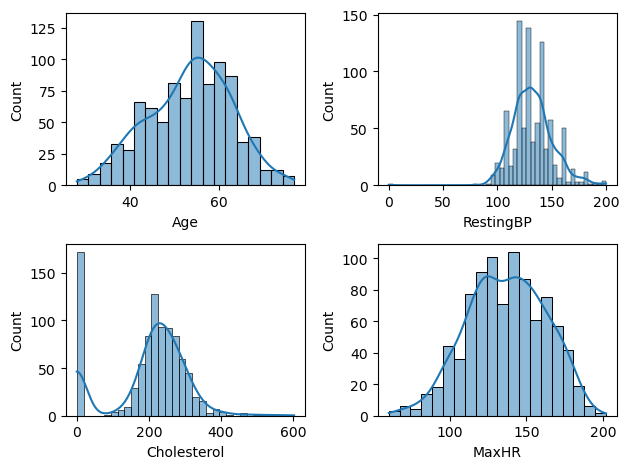

In [26]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)


plt.tight_layout()

In [27]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [28]:
#its not possible 0 value for cholesterol, so we will replace it with mean value of cholesterol
df['Cholesterol'] = df['Cholesterol'].replace(0,df['Cholesterol'].mean())
df['Cholesterol'].value_counts()

Cholesterol
198.799564    172
254.000000     11
223.000000     10
220.000000     10
230.000000      9
             ... 
392.000000      1
316.000000      1
153.000000      1
466.000000      1
131.000000      1
Name: count, Length: 222, dtype: int64

In [ ]:
#its not possible 0 value for RestingBP, so we will replace it with mean value of RestingBP
resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

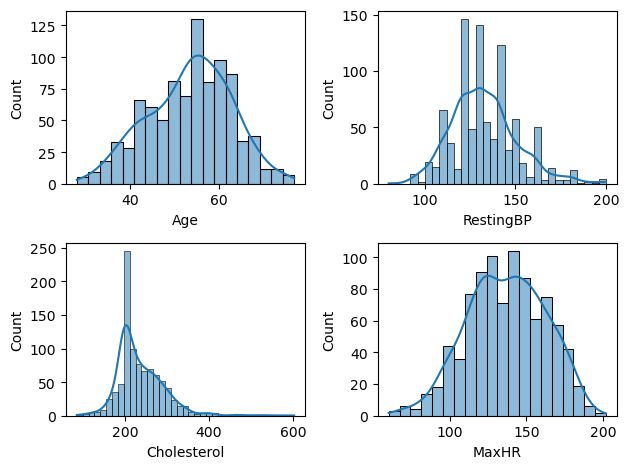

In [30]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)


plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

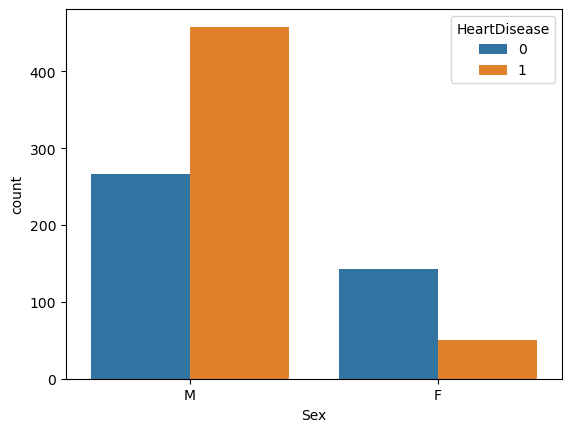

In [32]:
sns.countplot(x = df['Sex'],hue = df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

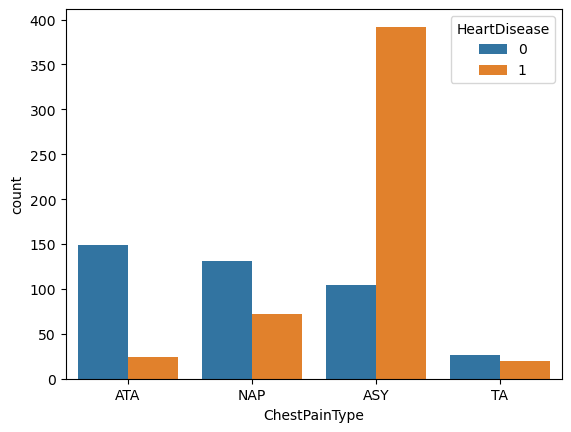

In [33]:
sns.countplot(x = df['ChestPainType'],hue = df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

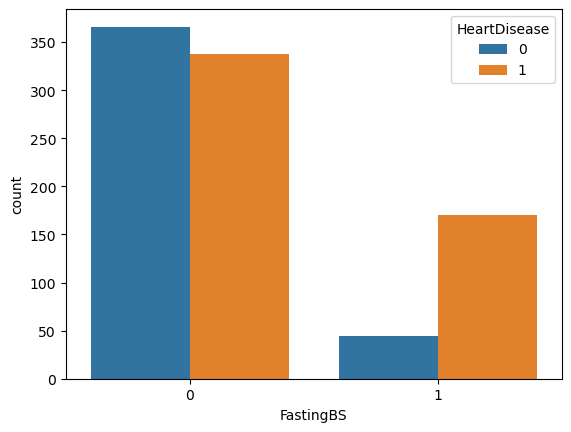

In [34]:
sns.countplot(x = df['FastingBS'],hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

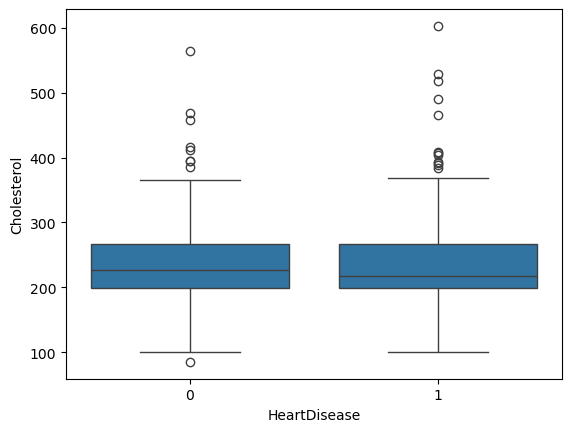

In [35]:
sns.boxplot(x = 'HeartDisease', y = 'Cholesterol',data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

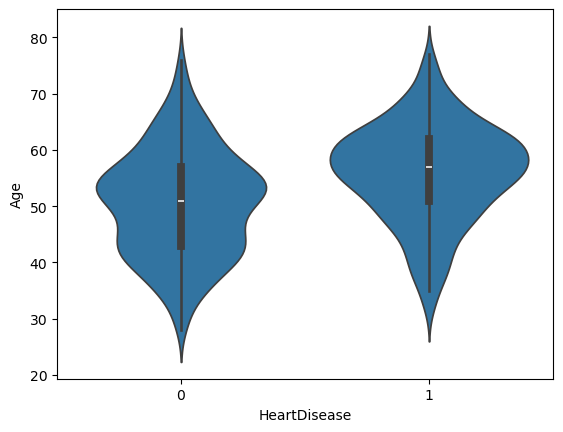

In [36]:
sns.violinplot(x='HeartDisease', y='Age', data=df)

<Axes: >

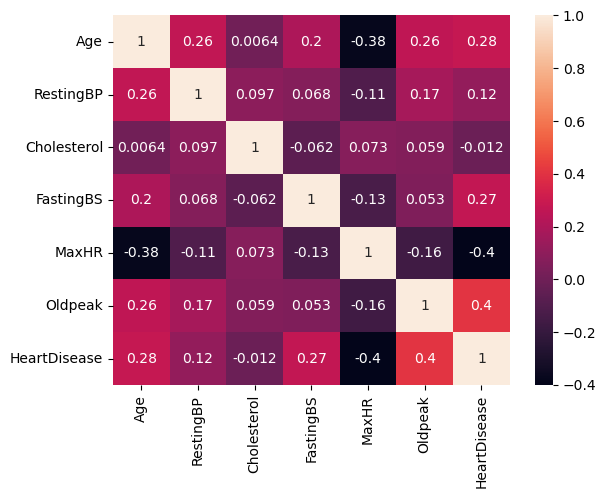

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Data perprocessing and cleaning

In [38]:
df_encode = pd.get_dummies(df,drop_first=True)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [39]:
df_encode = df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [40]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.943031,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-0.992670,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.836478,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.388873,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.726289,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


Feature engineering and Extraction

In [41]:
from scipy.stats import pearsonr

In [43]:
# Calculate Pearson correlation coefficients between selected features and 'heartDisease'
correlations = {}
for col in df_encode.columns:
    if col != 'HeartDisease':
        corr, _ = pearsonr(df_encode[col], df_encode['HeartDisease'])
        correlations[col] = corr
# Print the correlation coefficients
for feature, corr in correlations.items():
    print(f"Correlation between {feature} and HeartDisease: {corr:.4f}")


Correlation between Age and HeartDisease: 0.2820
Correlation between RestingBP and HeartDisease: 0.1179
Correlation between Cholesterol and HeartDisease: -0.0141
Correlation between FastingBS and HeartDisease: 0.2673
Correlation between MaxHR and HeartDisease: -0.4004
Correlation between Oldpeak and HeartDisease: 0.3924
Correlation between Sex_M and HeartDisease: 0.3054
Correlation between ChestPainType_ATA and HeartDisease: -0.4019
Correlation between ChestPainType_NAP and HeartDisease: -0.2130
Correlation between ChestPainType_TA and HeartDisease: -0.0548
Correlation between RestingECG_Normal and HeartDisease: -0.0916
Correlation between RestingECG_ST and HeartDisease: 0.1025
Correlation between ExerciseAngina_Y and HeartDisease: 0.4943
Correlation between ST_Slope_Flat and HeartDisease: 0.5541
Correlation between ST_Slope_Up and HeartDisease: -0.6222


In [45]:
# Select features for the final dataset based on correlation analysis
selected_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'FastingBS']
final_df = df_encode[selected_features + ['HeartDisease']]

In [47]:
# Perform Chi-Square tests for categorical features against the binned 'HeartDisease' variable
from scipy.stats import chi2_contingency
import pandas as pd
alpha = 0.05

categorical_features = ['Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'FastingBS']
chi2_results = {}

for feature in categorical_features:
    contingency_table = pd.crosstab(final_df[feature], final_df['HeartDisease'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    chi2_results[feature] = (chi2, p_value)

# Print the Chi-Square test results
for feature, (chi2, p_value) in chi2_results.items():
    print(f"Chi-Square test for {feature}: chi2 = {chi2:.4f}, p-value = {p_value:.4f}")





Chi-Square test for Sex_M: chi2 = 84.1451, p-value = 0.0000
Chi-Square test for ChestPainType_ATA: chi2 = 146.2363, p-value = 0.0000
Chi-Square test for ChestPainType_NAP: chi2 = 40.6087, p-value = 0.0000
Chi-Square test for ChestPainType_TA: chi2 = 2.2738, p-value = 0.1316
Chi-Square test for FastingBS: chi2 = 64.3207, p-value = 0.0000


In [48]:
# Based on the Chi-Square test results, we will keep all features that have a significant association with the binned 'HeartDisease' variable. In this case, we will keep 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', and 'FastingBS' as they have p-values less than 0.05.
final_df = final_df[selected_features + ['HeartDisease']]
final_df



,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,FastingBS,HeartDisease
0,-1.433140,0.414885,0.943031,1.382928,-0.727592,1,1,0,0,0,0
1,-0.478484,1.527224,-0.992670,0.754157,0.282891,0,0,1,0,0,1
2,-1.751359,-0.141284,0.836478,-1.525138,-0.727592,1,1,0,0,0,0
3,-0.584556,0.303651,-0.388873,-1.132156,0.282891,0,0,0,0,0,1
4,0.051881,0.971054,-0.726289,-0.581981,-0.727592,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.499063,-0.188999,0.282891,1,0,0,1,0,1
914,1.536902,0.637353,-0.761807,0.164684,2.303858,1,0,0,0,1,1
915,0.370100,-0.141284,-1.862847,-0.857069,0.282891,1,0,0,0,0,1
916,0.370100,-0.141284,0.001818,1.461525,-0.727592,0,1,0,0,0,1
